In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv(r"C:\Calibo\Unsupervised_customer churn\cleaned_customerchurn_dataset.csv")
df

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
176,CUST-1015,19.0,63000.0,38.0,64.24,1.0,13.0,7.0,Monthly,Credit Card,South,Premium,Yes
177,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
178,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes


In [ ]:
# Display the first five rows
display(df.head())

# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Check column names
print(df.columns.tolist())

# Check data types and missing values
df.info()


,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


Dataset shape: (180, 13)
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            180 non-null    str    
 1   Age                    180 non-null    float64
 2   Annual_Income          180 non-null    float64
 3   Tenure_Months          180 non-null    float64
 4   Monthly_Charges        180 non-null    float64
 5   Support_Calls_Last_3M  180 non-null    float64
 6   Data_Usage_GB          180 non-null    float64
 7   Satisfaction_Score     180 non-null    float64
 8   Contract_Type          180 non-null    str    
 9   Payment_Method         180 non-null    str    
 10  Region                 180 non-null    str   

In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values:
Customer_ID              0
Age                      0
Annual_Income            0
Tenure_Months            0
Monthly_Charges          0
Support_Calls_Last_3M    0
Data_Usage_GB            0
Satisfaction_Score       0
Contract_Type            0
Payment_Method           0
Region                   0
Plan_Type                0
Churn                    0
dtype: int64
Duplicate rows: 0


In [5]:
# Summary of numerical columns
display(df.describe())

# Summary of categorical columns
display(df.describe(include="object"))

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,36.311111,65188.333333,38.627778,74.508333,3.055556,18.667222,5.761111
std,8.561502,21655.753296,19.372569,26.184246,1.584570,8.142247,2.811318
min,18.000000,8600.000000,1.000000,0.000000,0.000000,0.800000,1.000000
25%,31.000000,50800.000000,25.000000,58.035000,2.000000,13.150000,4.000000
50%,36.000000,64700.000000,38.000000,72.900000,3.000000,18.800000,6.000000
75%,41.000000,76650.000000,53.250000,88.750000,4.000000,24.125000,8.000000
max,63.000000,120900.000000,72.000000,151.180000,7.000000,44.000000,10.000000


C:\Users\KEERTHI\AppData\Local\Temp\ipykernel_26696\781560298.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,Customer_ID,Contract_Type,Payment_Method,Region,Plan_Type,Churn
count,180,180,180,180,180,180
unique,180,3,5,4,3,2
top,CUST-1020,Monthly,UPI,North,Standard,Yes
freq,1,104,48,51,94,94


In [6]:
for column in df.columns:
    print("\nColumn:", column)
    print("Unique values:", df[column].unique())
    print("Value counts:")
    print(df[column].value_counts(dropna=False))


Column: Customer_ID
Unique values: <ArrowStringArray>
['CUST-1020', 'CUST-1043', 'CUST-1157', 'CUST-1112', 'CUST-1149', 'CUST-1016',
 'CUST-1025', 'CUST-1069', 'CUST-1118', 'CUST-1099',
 ...
 'CUST-1088', 'CUST-1075', 'CUST-1122', 'CUST-1021', 'CUST-1072', 'CUST-1107',
 'CUST-1015', 'CUST-1093', 'CUST-1180', 'CUST-1103']
Length: 180, dtype: str
Value counts:
Customer_ID
CUST-1020    1
CUST-1043    1
CUST-1157    1
CUST-1112    1
CUST-1149    1
            ..
CUST-1107    1
CUST-1015    1
CUST-1093    1
CUST-1180    1
CUST-1103    1
Name: count, Length: 180, dtype: int64

Column: Age
Unique values: [22. 35. 55. 36. 41. 30. 31. 40. 24. 39. 48. 29. 26. 32. 51. 28. 46. 42.
 27. 61. 44. 45. 33. 50. 38. 37. 23. 34. 43. 47. 25. 21. 49. 20. 52. 58.
 18. 19. 63.]
Value counts:
Age
36.0    21
39.0    14
44.0    11
31.0    10
38.0     8
34.0     8
28.0     7
33.0     7
37.0     7
41.0     6
40.0     6
24.0     6
35.0     5
30.0     5
29.0     5
51.0     5
46.0     5
22.0     4
55.0     4
27.0   

In [7]:
# Numerical features
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

# Categorical features
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

# Select features for clustering
X = df[numerical_columns + categorical_columns].copy()

print("Features selected for clustering:")
print(X.columns.tolist())

print("Shape:", X.shape)

Features selected for clustering:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']
Shape: (180, 11)


In [8]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    dtype=int
)

display(X_encoded.head())

print("Encoded data shape:", X_encoded.shape)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,...,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,Region_South,Region_West,Plan_Type_Basic,Plan_Type_Premium,Plan_Type_Standard
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,0,0,1,...,0,0,0,0,0,1,0,1,0,0
2,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,0,0,1,...,1,0,0,0,0,0,1,0,1,0


Encoded data shape: (180, 22)


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

print("Scaled data shape:", X_scaled.shape)
print("First five rows:")
print(X_scaled[:5])

Scaled data shape: (180, 22)
First five rows:
[[-1.67622814 -1.91652452 -1.43010681 -0.44227152  2.49622707  0.21340685
  -0.27148627 -0.63737744 -0.39223227  0.85485041  1.70676404 -0.56879646
  -0.54310591 -0.60302269 -0.07474351 -0.48257301  1.59041245 -0.61159284
  -0.58590407 -0.59446065 -0.52592371  0.95650071]
 [-0.15356748  0.19502507 -1.1195266   0.04295695  1.86338077 -0.1437537
   1.1553029  -0.63737744 -0.39223227  0.85485041  1.70676404 -0.56879646
  -0.54310591 -0.60302269 -0.07474351 -0.48257301 -0.62876771  1.63507473
  -0.58590407  1.68219714 -0.52592371 -1.04547753]
 [ 2.18898736 -0.02261272  0.53690115  0.70243874 -0.03515813  0.36119742
  -1.69827544 -0.63737744 -0.39223227  0.85485041 -0.58590407 -0.56879646
  -0.54310591  1.6583124  -0.07474351 -0.48257301 -0.62876771 -0.61159284
   1.70676404  1.68219714 -0.52592371 -1.04547753]
 [-0.03643974  0.68586773 -1.53363354  0.42746318 -1.93369702  1.92531428
   1.1553029  -0.63737744 -0.39223227  0.85485041 -0.58590407 

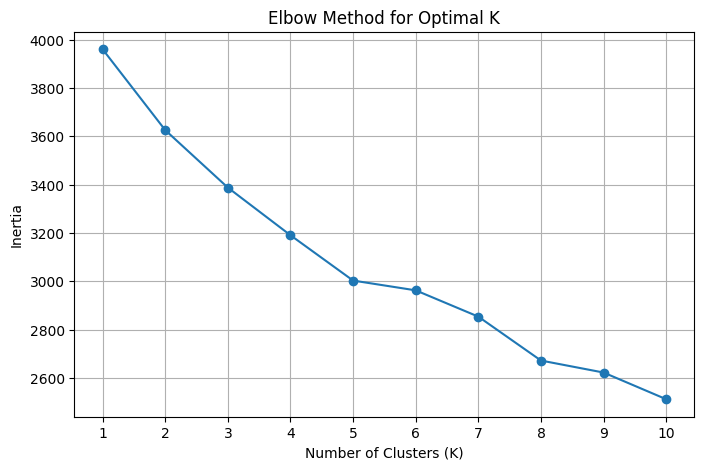

In [55]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("K-Means model created successfully.")
print("Cluster centers shape:", kmeans.cluster_centers_.shape)

K-Means model created successfully.
Cluster centers shape: (3, 22)


In [12]:
df["KMeans_Cluster"] = kmeans.labels_

display(df.head())

print("Number of customers in each cluster:")
print(df["KMeans_Cluster"].value_counts().sort_index())

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,KMeans_Cluster
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes,1
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes,1
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes,1
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes,1
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes,1


Number of customers in each cluster:
KMeans_Cluster
0     24
1    104
2     52
Name: count, dtype: int64


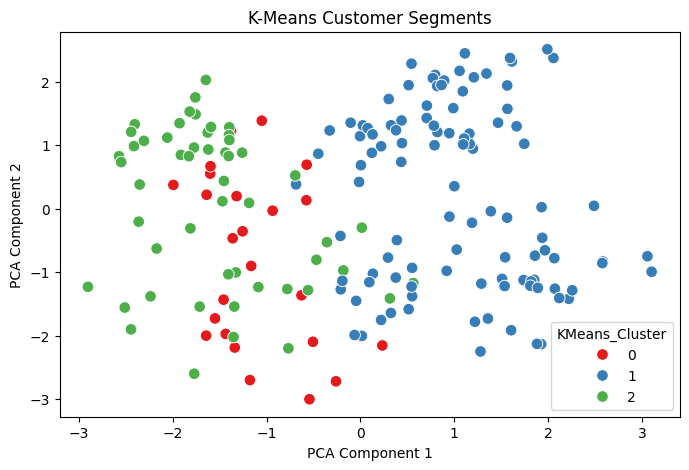

Explained variance ratio: [0.09295252 0.08627739]
Total variance explained: 0.1792299107727286


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plot_kmeans = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "KMeans_Cluster": kmeans.labels_
})

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_kmeans,
    x="PCA_1",
    y="PCA_2",
    hue="KMeans_Cluster",
    palette="Set1",
    s=70
)

plt.title("K-Means Customer Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

In [14]:
cluster_summary = df.groupby("KMeans_Cluster")[
    numerical_columns
].mean().round(2)

display(cluster_summary)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
KMeans_Cluster,,,,,,,
0,35.21,64087.50,37.71,76.30,2.96,16.55,5.83
1,36.35,64200.96,40.27,71.72,3.01,19.58,5.73
2,36.75,67671.15,35.77,79.26,3.19,17.83,5.79


In [15]:
for column in categorical_columns:
    print("\n", column, "by K-Means Cluster")

    display(
        pd.crosstab(
            df["KMeans_Cluster"],
            df[column],
            normalize="index"
        ).round(2)
    )


 Contract_Type by K-Means Cluster


Contract_Type,1 Year,2 Year,Monthly
KMeans_Cluster,,,
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0



 Payment_Method by K-Means Cluster


Payment_Method,Bank Transfer,Credit Card,Debit Card,UPI,Unknown
KMeans_Cluster,,,,,
0,0.21,0.12,0.33,0.33,0.00
1,0.24,0.28,0.20,0.27,0.01
2,0.31,0.23,0.23,0.23,0.00



 Region by K-Means Cluster


Region,East,North,South,West
KMeans_Cluster,,,,
0,0.08,0.38,0.21,0.33
1,0.16,0.29,0.30,0.25
2,0.29,0.23,0.25,0.23



 Plan_Type by K-Means Cluster


Plan_Type,Basic,Premium,Standard
KMeans_Cluster,,,
0,0.17,0.33,0.50
1,0.30,0.20,0.50
2,0.23,0.19,0.58


In [16]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score
score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette Score:", score)

Silhouette Score: 0.10700779701900281


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0863
K = 3, Silhouette Score = 0.1070
K = 4, Silhouette Score = 0.0994
K = 5, Silhouette Score = 0.0880
K = 6, Silhouette Score = 0.0911
K = 7, Silhouette Score = 0.0763
K = 8, Silhouette Score = 0.1052
K = 9, Silhouette Score = 0.0849
K = 10, Silhouette Score = 0.0873


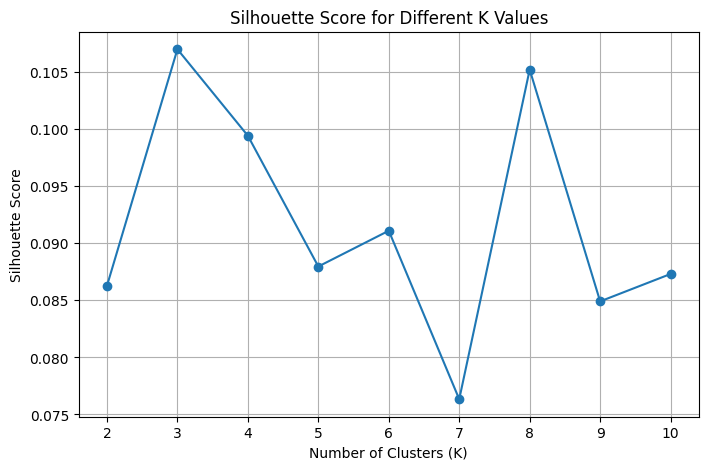

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Hierarchical Clustering

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [20]:
print("Scaled data shape:", X_scaled.shape)
print("Number of customers:", X_scaled.shape[0])

Scaled data shape: (180, 22)
Number of customers: 180


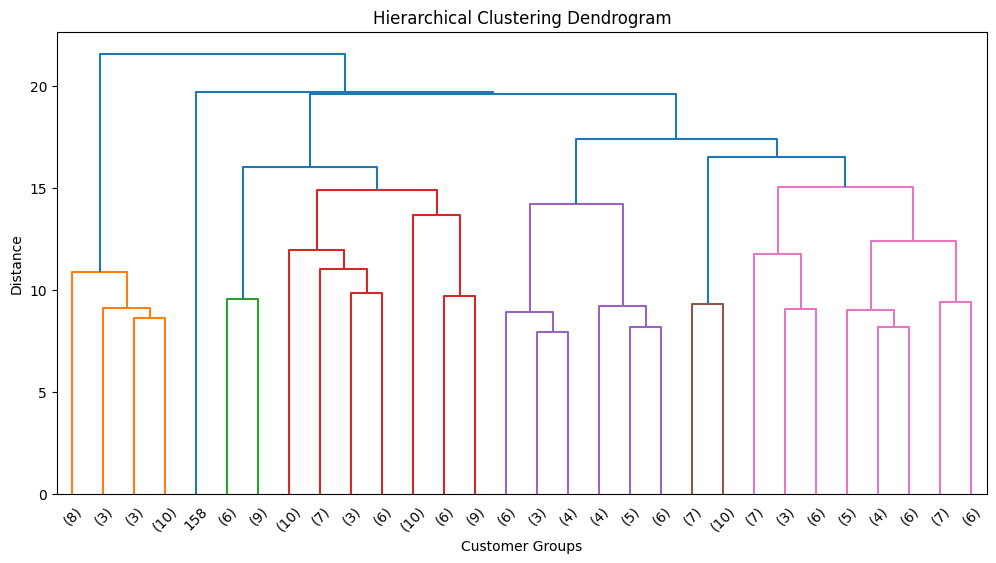

In [21]:
# Create the linkage matrix
Z = linkage(X_scaled, method="ward")

# Plot the dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Groups")
plt.ylabel("Distance")
plt.show()

In [22]:
n_clusters = 3

In [23]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

print("Hierarchical clustering completed.")
print("Cluster labels:", np.unique(hierarchical_labels))

Hierarchical clustering completed.
Cluster labels: [0 1 2]


In [24]:
df["Hierarchical_Cluster"] = hierarchical_labels

display(df.head())

print("Customers in each cluster:")
print(df["Hierarchical_Cluster"].value_counts().sort_index())

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,KMeans_Cluster,Hierarchical_Cluster
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes,1,0
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes,1,0
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes,1,0
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes,1,0
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes,1,0


Customers in each cluster:
Hierarchical_Cluster
0    155
1     24
2      1
Name: count, dtype: int64


In [25]:
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Silhouette Score:",
      round(hierarchical_silhouette, 4))

Hierarchical Clustering Silhouette Score: 0.0939


In [26]:
silhouette_scores_hierarchical = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores_hierarchical.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.0881


K = 3, Silhouette Score = 0.0939
K = 4, Silhouette Score = 0.0670
K = 5, Silhouette Score = 0.0696
K = 6, Silhouette Score = 0.0467
K = 7, Silhouette Score = 0.0541
K = 8, Silhouette Score = 0.0624
K = 9, Silhouette Score = 0.0719
K = 10, Silhouette Score = 0.0790


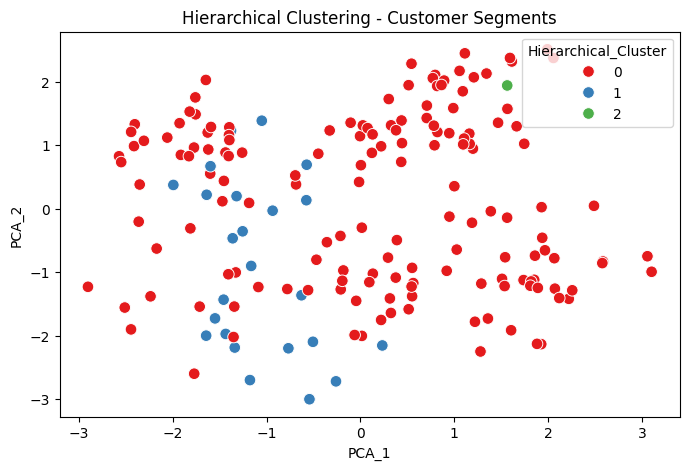

Explained variance ratio: [0.09295252 0.08627739]
Total variance explained: 0.1792299107727286


In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_hierarchical = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "Hierarchical_Cluster": hierarchical_labels
})

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_hierarchical,
    x="PCA_1",
    y="PCA_2",
    hue="Hierarchical_Cluster",
    palette="Set1",
    s=70
)

plt.title("Hierarchical Clustering - Customer Segments")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

In [28]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

cluster_summary = df.groupby("Hierarchical_Cluster")[
    numerical_columns
].mean().round(2)

display(cluster_summary)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
Hierarchical_Cluster,,,,,,,
0,36.71,65095.48,38.95,74.28,3.06,19.02,5.72
1,33.96,64041.67,36.58,76.76,3.08,16.30,5.88
2,31.00,107100.00,38.00,55.24,2.00,20.60,9.00


In [29]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

for column in categorical_columns:
    print("\n", column, "by Hierarchical Cluster")

    display(
        pd.crosstab(
            df["Hierarchical_Cluster"],
            df[column],
            normalize="index"
        ).round(2)
    )


 Contract_Type by Hierarchical Cluster


Contract_Type,1 Year,2 Year,Monthly
Hierarchical_Cluster,,,
0,0.33,0.01,0.66
1,0.04,0.96,0.00
2,0.00,0.00,1.00



 Payment_Method by Hierarchical Cluster


Payment_Method,Bank Transfer,Credit Card,Debit Card,UPI,Unknown
Hierarchical_Cluster,,,,,
0,0.27,0.26,0.21,0.26,0.0
1,0.17,0.12,0.38,0.33,0.0
2,0.00,0.00,0.00,0.00,1.0



 Region by Hierarchical Cluster


Region,East,North,South,West
Hierarchical_Cluster,,,,
0,0.21,0.26,0.28,0.25
1,0.04,0.42,0.21,0.33
2,0.00,1.00,0.00,0.00



 Plan_Type by Hierarchical Cluster


Plan_Type,Basic,Premium,Standard
Hierarchical_Cluster,,,
0,0.27,0.20,0.53
1,0.21,0.33,0.46
2,0.00,0.00,1.00


### DBSCAN

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

In [31]:
print("Scaled data shape:", X_scaled.shape)
print("Number of customers:", X_scaled.shape[0])

Scaled data shape: (180, 22)
Number of customers: 180


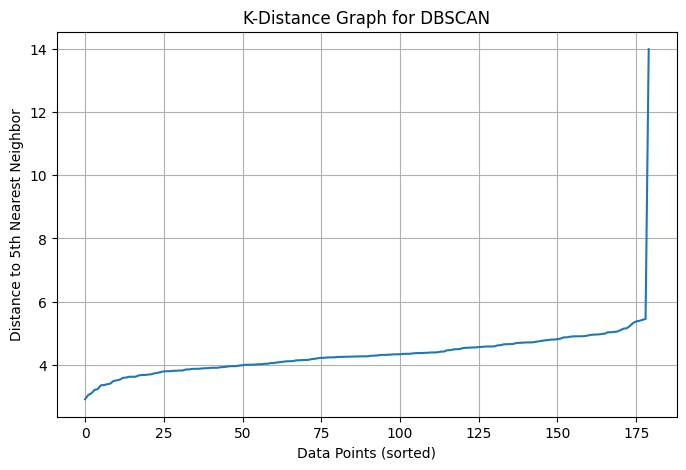

In [32]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Sort the distances to the 5th nearest neighbor
distances_sorted = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(distances_sorted)

plt.xlabel("Data Points (sorted)")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("K-Distance Graph for DBSCAN")
plt.grid(True)
plt.show()

In [33]:
dbscan_model = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

print("DBSCAN completed.")
print("Cluster labels:", np.unique(dbscan_labels))

DBSCAN completed.
Cluster labels: [-1]


In [34]:
print("Customers in each cluster:")

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

for label, count in zip(unique_labels, counts):
    if label == -1:
        print(f"Noise points: {count}")
    else:
        print(f"Cluster {label}: {count} customers")

Customers in each cluster:
Noise points: 180


In [35]:
# Make sure X_scaled and df have the same rows in the same order
if len(df) != len(dbscan_labels):
    raise ValueError(
        "df and X_scaled have different row counts. "
        "Use the exact dataset rows used for scaling."
    )

df["DBSCAN_Cluster"] = dbscan_labels

display(df.head())

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,Monthly,Bank Transfer,North,Standard,Yes,1,0,-1
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes,1,0,-1
2,CUST-1157,55.0,64700.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes,1,0,-1
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes,1,0,-1
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes,1,0,-1


In [36]:
# Exclude noise points
mask = dbscan_labels != -1

cluster_labels_without_noise = dbscan_labels[mask]
X_without_noise = X_scaled[mask]

number_of_clusters = len(np.unique(cluster_labels_without_noise))

if number_of_clusters >= 2:
    score = silhouette_score(
        X_without_noise,
        cluster_labels_without_noise
    )
    print("DBSCAN Silhouette Score:", round(score, 4))
else:
    print(
        "Silhouette Score cannot be calculated because "
        "DBSCAN found fewer than two non-noise clusters."
    )

Silhouette Score cannot be calculated because DBSCAN found fewer than two non-noise clusters.


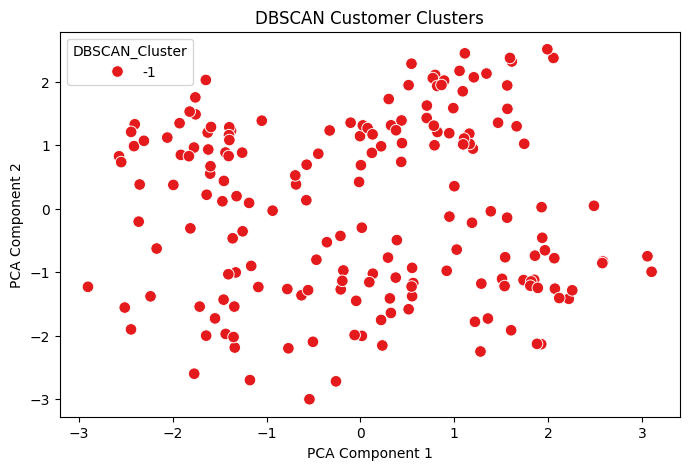

Explained variance ratio: [0.09295252 0.08627739]
Total variance explained: 0.1792


In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_dbscan = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "DBSCAN_Cluster": dbscan_labels
})

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_dbscan,
    x="PCA_1",
    y="PCA_2",
    hue="DBSCAN_Cluster",
    palette="Set1",
    s=70
)

plt.title("DBSCAN Customer Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

In [38]:
numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

cluster_summary = df.groupby("DBSCAN_Cluster")[
    numerical_columns
].mean().round(2)

display(cluster_summary)

,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
DBSCAN_Cluster,,,,,,,
-1,36.31,65188.33,38.63,74.51,3.06,18.67,5.76


In [39]:
for eps_value in [0.3, 0.5, 0.7, 1.0]:
    model = DBSCAN(
        eps=eps_value,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    number_of_clusters = len(set(labels) - {-1})
    noise_count = np.sum(labels == -1)

    print(
        f"eps={eps_value} | "
        f"Clusters={number_of_clusters} | "
        f"Noise points={noise_count}"
    )

eps=0.3 | Clusters=0 | Noise points=180
eps=0.5 | Clusters=0 | Noise points=180
eps=0.7 | Clusters=0 | Noise points=180
eps=1.0 | Clusters=0 | Noise points=180


### PCA

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [41]:
print("Scaled data shape:", X_scaled.shape)
print("Number of customers:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])

Scaled data shape: (180, 22)
Number of customers: 180
Number of features: 22


In [42]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original data shape:", X_scaled.shape)
print("PCA data shape:", X_pca.shape)

Original data shape: (180, 22)
PCA data shape: (180, 2)


In [43]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.09295252 0.08627739]
Total variance explained:
0.1792299107727286


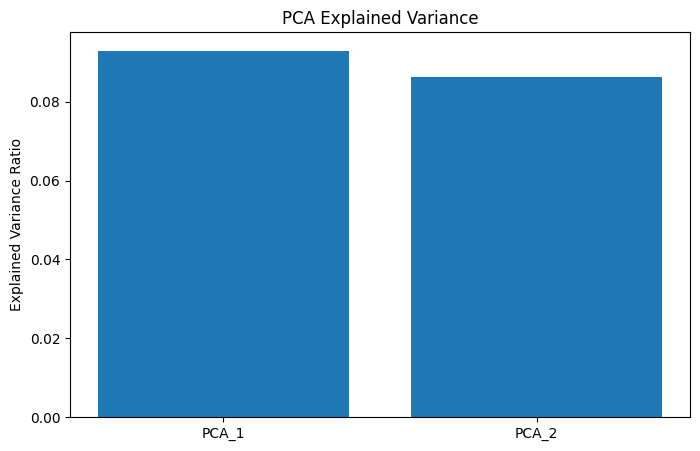

In [44]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["PCA_1", "PCA_2"],
    pca.explained_variance_ratio_
)

plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

,PCA_1,PCA_2
0,1.160515,1.180012
1,1.563389,-0.143250
2,1.509292,-1.106783
3,0.796445,2.105636
4,0.324983,-1.643992


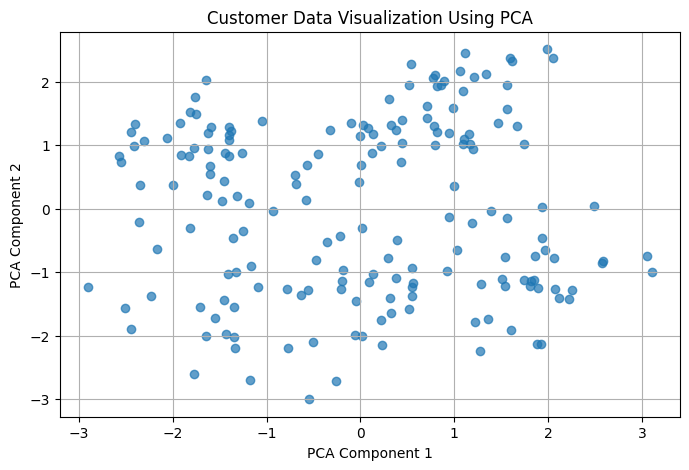

In [45]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA_1", "PCA_2"]
)

display(pca_df.head())

plt.figure(figsize=(8, 5))

plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"],
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Data Visualization Using PCA")
plt.grid(True)
plt.show()

In [46]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features:", X_pca_95.shape[1])
print(
    "Total variance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Original number of features: 22
Reduced number of features: 17
Total variance retained: 0.9720375401680362


### Apriori Algorithm


In [47]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [49]:
categorical_columns = [
    "Contract_Type",
    "Payment_Method",
    "Region",
    "Plan_Type"
]

numerical_columns = [
    "Age",
    "Annual_Income",
    "Tenure_Months",
    "Monthly_Charges",
    "Support_Calls_Last_3M",
    "Data_Usage_GB",
    "Satisfaction_Score"
]

In [50]:
apriori_df = df[categorical_columns].copy()

for column in numerical_columns:
    apriori_df[column] = pd.qcut(
        df[column],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    ).astype(str)

apriori_df.head()

,Contract_Type,Payment_Method,Region,Plan_Type,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
0,Monthly,Bank Transfer,North,Standard,Low,Low,Low,Low,High,Medium,Medium
1,Monthly,Bank Transfer,South,Basic,Medium,Medium,Low,Medium,High,Medium,High
2,Monthly,UPI,West,Basic,High,Medium,Medium,High,Medium,Medium,Low
3,Monthly,UPI,South,Standard,Medium,High,Low,High,Low,High,High
4,Monthly,Debit Card,West,Premium,High,High,High,Low,Low,High,High


In [51]:
transaction_data = pd.get_dummies(
    apriori_df,
    dtype=bool
)

transaction_data.head()

,Contract_Type_1 Year,Contract_Type_2 Year,Contract_Type_Monthly,Payment_Method_Bank Transfer,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_UPI,Payment_Method_Unknown,Region_East,Region_North,...,Monthly_Charges_Medium,Support_Calls_Last_3M_High,Support_Calls_Last_3M_Low,Support_Calls_Last_3M_Medium,Data_Usage_GB_High,Data_Usage_GB_Low,Data_Usage_GB_Medium,Satisfaction_Score_High,Satisfaction_Score_Low,Satisfaction_Score_Medium
0,False,False,True,True,False,False,False,False,False,True,...,False,True,False,False,False,False,True,False,False,True
1,False,False,True,True,False,False,False,False,False,False,...,True,True,False,False,False,False,True,True,False,False
2,False,False,True,False,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,True,False
3,False,False,True,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,True,False,False
4,False,False,True,False,False,True,False,False,False,False,...,False,False,True,False,True,False,False,True,False,False


In [52]:
frequent_itemsets = apriori(
    transaction_data,
    min_support=0.10,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets

,support,itemsets
2,0.577778,frozenset({Contract_Type_Monthly})
13,0.522222,frozenset({Plan_Type_Standard})
28,0.461111,frozenset({Support_Calls_Last_3M_Medium})
27,0.361111,frozenset({Support_Calls_Last_3M_Low})
15,0.355556,frozenset({Age_Low})
...,...,...
276,0.100000,"frozenset({Data_Usage_GB_Low, Monthly_Charges_..."
42,0.100000,"frozenset({Data_Usage_GB_Low, Contract_Type_1 ..."
43,0.100000,"frozenset({Contract_Type_1 Year, Data_Usage_GB..."
293,0.100000,"frozenset({Data_Usage_GB_High, Satisfaction_Sc..."


In [53]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.50
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
89,frozenset({Support_Calls_Last_3M_High}),frozenset({Satisfaction_Score_Medium}),0.105556,0.593750,1.752049
57,frozenset({Payment_Method_Debit Card}),frozenset({Tenure_Months_High}),0.127778,0.560976,1.740959
75,frozenset({Plan_Type_Premium}),frozenset({Data_Usage_GB_Low}),0.111111,0.512821,1.538462
60,frozenset({Payment_Method_Credit Card}),frozenset({Annual_Income_Medium}),0.122222,0.500000,1.500000
92,"frozenset({Data_Usage_GB_Low, Contract_Type_Mo...",frozenset({Support_Calls_Last_3M_Low}),0.100000,0.529412,1.466063
...,...,...,...,...,...
53,"frozenset({Plan_Type_Standard, Support_Calls_L...",frozenset({Contract_Type_Monthly}),0.133333,0.521739,0.903010
101,"frozenset({Age_Low, Plan_Type_Standard})",frozenset({Contract_Type_Monthly}),0.100000,0.514286,0.890110
76,"frozenset({Plan_Type_Standard, Data_Usage_GB_M...",frozenset({Contract_Type_Monthly}),0.111111,0.512821,0.887574
68,frozenset({Payment_Method_Debit Card}),frozenset({Contract_Type_Monthly}),0.116667,0.512195,0.886492


In [54]:
strong_rules = rules[
    (rules["confidence"] >= 0.60) &
    (rules["lift"] > 1)
]

strong_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
66,"frozenset({Plan_Type_Standard, Satisfaction_Sc...",frozenset({Support_Calls_Last_3M_Medium}),0.116667,0.636364,1.380066
81,"frozenset({Tenure_Months_Low, Plan_Type_Standa...",frozenset({Support_Calls_Last_3M_Medium}),0.105556,0.633333,1.373494
61,"frozenset({Plan_Type_Standard, Age_Medium})",frozenset({Support_Calls_Last_3M_Medium}),0.122222,0.611111,1.325301
80,"frozenset({Support_Calls_Last_3M_Medium, Month...",frozenset({Plan_Type_Standard}),0.105556,0.678571,1.299392
93,"frozenset({Data_Usage_GB_Low, Support_Calls_La...",frozenset({Contract_Type_Monthly}),0.100000,0.720000,1.246154
62,"frozenset({Support_Calls_Last_3M_Medium, Age_M...",frozenset({Plan_Type_Standard}),0.122222,0.647059,1.239049
73,"frozenset({Data_Usage_GB_Medium, Support_Calls...",frozenset({Plan_Type_Standard}),0.116667,0.636364,1.218569
67,"frozenset({Support_Calls_Last_3M_Medium, Satis...",frozenset({Plan_Type_Standard}),0.116667,0.636364,1.218569
95,"frozenset({Support_Calls_Last_3M_Medium, Annua...",frozenset({Plan_Type_Standard}),0.100000,0.620690,1.188555
7,frozenset({Data_Usage_GB_Medium}),frozenset({Plan_Type_Standard}),0.216667,0.619048,1.185410
